# Лабораторная работа 3
### Улучшить качетсво изображения

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('./picture.jpg')

def getPSNR(I1, I2):
    s1 = cv.absdiff(I1, I2)
    s1 = np.float32(s1)
    s1 = s1 * s1
    sse = s1.sum()
    if sse <= 1e-10:
        return 0
    else:
        shape = I1.shape
        p = 1
        for i in shape:
            p *= i
        mse = 1.0 * sse / p
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr

def getSSIM(i1, i2):
    C1 = 6.5025
    C2 = 58.5225
    I1 = np.float32(i1)
    I2 = np.float32(i2)
    I2_2 = I2 * I2
    I1_2 = I1 * I1
    I1_I2 = I1 * I2

    mu1 = cv.GaussianBlur(I1, (11, 11), 1.5)
    mu2 = cv.GaussianBlur(I2, (11, 11), 1.5)
    mu1_2 = mu1 * mu1
    mu2_2 = mu2 * mu2
    mu1_mu2 = mu1 * mu2
    sigma1_2 = cv.GaussianBlur(I1_2, (11, 11), 1.5)
    sigma1_2 -= mu1_2
    sigma2_2 = cv.GaussianBlur(I2_2, (11, 11), 1.5)
    sigma2_2 -= mu2_2
    sigma12 = cv.GaussianBlur(I1_I2, (11, 11), 1.5)
    sigma12 -= mu1_mu2
    t1 = 2 * mu1_mu2 + C1
    t2 = 2 * sigma12 + C2
    t3 = t1 * t2
    t1 = mu1_2 + mu2_2 + C1
    t2 = sigma1_2 + sigma2_2 + C2
    t1 = t1 * t2
    ssim_map = cv.divide(t3, t1)
    ssim = cv.mean(ssim_map)
    ssim = ssim[:3]
    return ssim

# Приводим вид изображения к прямоугольному

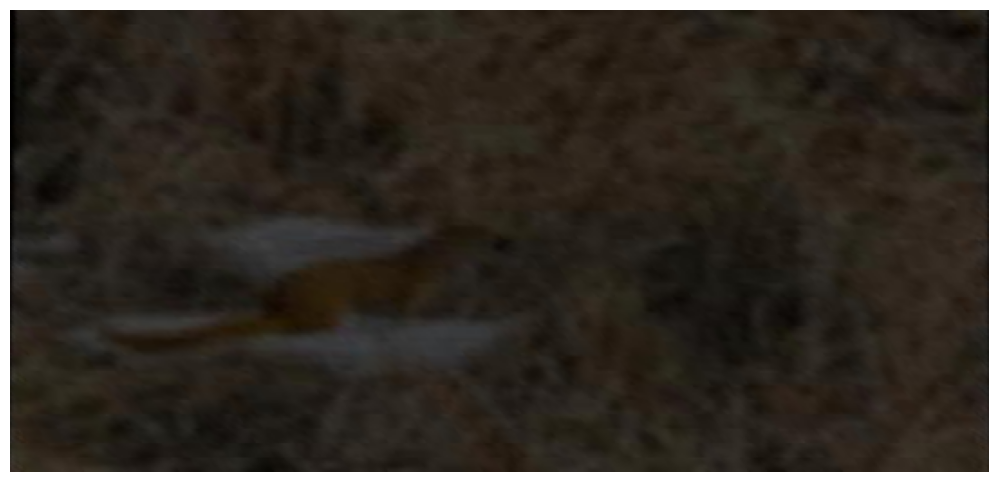

In [16]:
parallelogram = np.array([
    [125, 0],
    [542, 0],
    [413, 256],
    [0, 256]
], dtype=np.float32)

rectangle = np.array([
    [0, 0],
    [542, 0],
    [542, 256],
    [0, 256]
], dtype=np.float32)

matrix = cv.getPerspectiveTransform(parallelogram, rectangle)

image = cv.warpPerspective(image, matrix, (542, 256))
rgb_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(15, 6))

plt.imshow(rgb_image)
plt.axis('off')
plt.show()

## В ходе эксперимента лучше всего себя показали последовательные операции удаления шума, улучшения контраста и повышения резкости

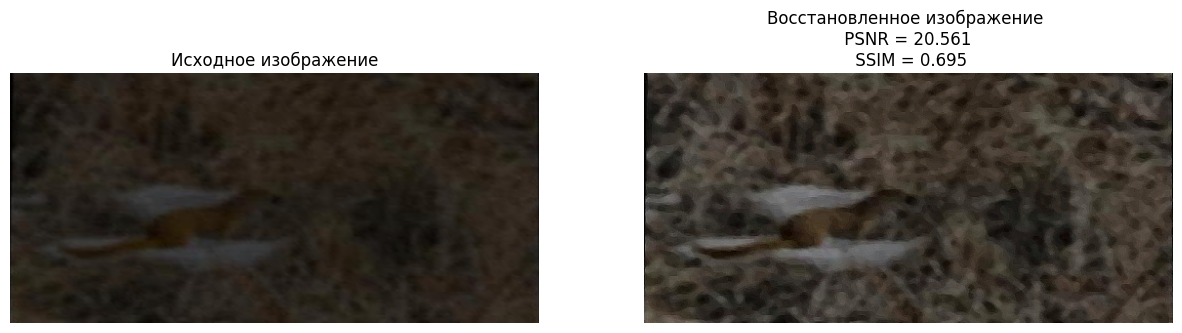

In [17]:
# Убираем шум медианным фильтром
denoised_color = cv.medianBlur(rgb_image, 5)

# Улучшение контраста (конструкция для цветного изображения)
lab = cv.cvtColor(denoised_color, cv.COLOR_RGB2LAB)
l, a, b = cv.split(lab)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_enhanced = clahe.apply(l)
lab_enhanced = cv.merge([l_enhanced, a, b])
contrast_enhanced_color = cv.cvtColor(lab_enhanced, cv.COLOR_LAB2RGB)

# Повышение резкости
kernel = np.array([[-0.25, -0.25, -0.25], [-0.25, 3, -0.25], [-0.25, -0.25, -0.25]])
sharpened = cv.filter2D(contrast_enhanced_color, -1, kernel)

psnr = getPSNR(rgb_image, sharpened)
ssim = getSSIM(rgb_image, sharpened)

plt.figure(figsize=(15, 5))
gs = plt.GridSpec(1, 2)

plt.subplot(gs[0])
plt.imshow(rgb_image)
plt.title(f'Исходное изображение')
plt.axis('off')

plt.subplot(gs[1])
plt.imshow(sharpened, cmap='gray')
plt.title(f'Восстановленное изображение \n '
          f'PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}')
plt.axis('off')

plt.show()
